In [4]:
import os

data_dir_1 = os.path.join('..', 'data', 'case_study_1')
data_dir_2 = os.path.join('..', 'data', 'case_study_2')
result_dir_1 = os.path.join('..', 'results', 'case_study_1')
result_dir_2 = os.path.join('..', 'results', 'case_study_2')

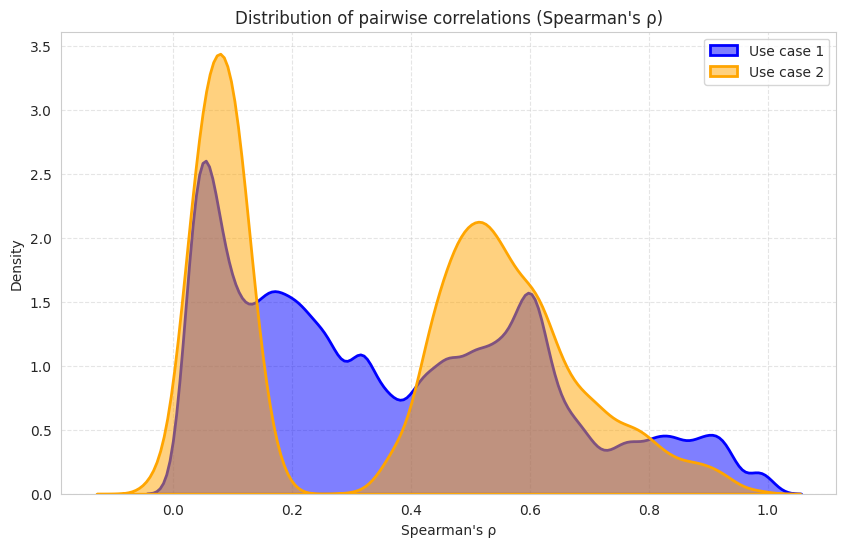

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load the CSV for data_dir_1
df1 = pd.read_csv(os.path.join(data_dir_1, 'correlations.csv'), sep=";")
df1 = df1[df1["source"] != df1["target"]]  # Exclude self-correlations
df1 = df1[df1["source"] < df1["target"]]   # Exclude reverse pairs

# Load the CSV for data_dir_2
df2 = pd.read_csv(os.path.join(data_dir_2, 'correlations.csv'), sep=";")
df2 = df2[df2["source"] != df2["target"]]  # Exclude self-correlations
df2 = df2[df2["source"] < df2["target"]]   # Exclude reverse pairs

# Plot the distributions as smooth curves (KDE)
plt.figure(figsize=(10, 6))
sns.kdeplot(df1["correlation"], fill=True, color="blue", linewidth=2, label="Use case 1", alpha=0.5)
sns.kdeplot(df2["spearman"], fill=True, color="orange", linewidth=2, label="Use case 2", alpha=0.5)

plt.xlabel("Spearman's ρ")
plt.ylabel("Density")
plt.title("Distribution of pairwise correlations (Spearman's ρ)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


# Feature importances latex table code generator

In [6]:
import json
import numpy as np
import pandas as pd
import os

nb_iter = 10
case = 1
dataset = 'valid'

# Load data
classifier_clusters = pd.read_csv(os.path.join(result_dir_1, f'classifier_{dataset}_clusters.csv'), delimiter=';')
max_train_size = classifier_clusters.loc[classifier_clusters['iteration'] == nb_iter, 'train_size'].max()
clusters = 4

selected_row = classifier_clusters[
    (classifier_clusters['train_size'] == max_train_size) &
    (classifier_clusters['nb_clusters'] == clusters)]

# Calculate mean F1-score for selected rows
mean_f1_score = selected_row['f1_score'].mean()

importances = []
for str_importance in selected_row['feature_importance'].tolist():
    # Clean and parse JSON
    cleaned_str = str_importance.replace("np.float64(", "").replace(")", "").replace("'", '"')
    importances.append(json.loads(cleaned_str))

# Collect all unique feature names across all dictionaries
all_features = set()
for imp in importances:
    all_features.update(imp.keys())
all_features = list(all_features)

# Initialize results with 0 for all features
results = {feature: {'mean': 0, 'min': 0, 'max': 0} for feature in all_features}

# Calculate mean, min, max for each feature (0 if missing)
for feature in all_features:
    values = []
    for imp in importances:
        values.append(imp.get(feature, 0))
    mean = np.mean(values)
    min_val = np.min(values)
    max_val = np.max(values)
    results[feature] = {'mean': mean, 'min': min_val, 'max': max_val}

# Sort features by descending mean importance
sorted_features = sorted(results.keys(), key=lambda x: results[x]['mean'], reverse=True)

# Generate LaTeX table
latex_table = r"""
\begin{table}
  \caption{""" + f'Feature importances on {clusters} clusters of {dataset} dataset of study case {case} (F1-score: {mean_f1_score:.3f})' + r"""
  \label{tab:""" + f'feat_{dataset}_{case}' + r"""}
  \begin{tabular}{lc}
  \toprule
  \textbf{Feature} & \textbf{Importance [min-max]} \\
  \midrule
""" + "\n".join(
    f"{feature.replace('_', ' ').replace('/', ' ').title()} & {results[feature]['mean']*100:.1f}\% [{results[feature]['min']*100:.1f}-{results[feature]['max']*100:.1f}] \\\\"
    for feature in sorted_features
) + r"""
  \bottomrule
  \end{tabular}
\end{table}
"""

print(latex_table)



\begin{table}
  \caption{Feature importances on 4 clusters of valid dataset of study case 1 (F1-score: 0.966)
  \label{tab:feat_valid_1}
  \begin{tabular}{lc}
  \toprule
  \textbf{Feature} & \textbf{Importance [min-max]} \\
  \midrule
Spatial Smoothing Fwhm & 71.5\% [71.2-72.2] \\
Signal Modeling Hrf Temporal Dispersion Derivs & 28.5\% [27.8-28.8] \\
  \bottomrule
  \end{tabular}
\end{table}


<>:60: SyntaxWarning: invalid escape sequence '\%'
<>:60: SyntaxWarning: invalid escape sequence '\%'
/home/ymerel/tmp/ipykernel_116558/2968843466.py:60: SyntaxWarning: invalid escape sequence '\%'
  f"{feature.replace('_', ' ').replace('/', ' ').title()} & {results[feature]['mean']*100:.1f}\% [{results[feature]['min']*100:.1f}-{results[feature]['max']*100:.1f}] \\\\"


In [7]:
import ast
import pandas as pd

classifier_valid_thresholds_1 = pd.read_csv(os.path.join(result_dir_1, f'classifier_valid_thresholds.csv'), delimiter=';')
max_train_size_1 = classifier_valid_thresholds_1.loc[classifier_valid_thresholds_1['iteration'] == nb_iter, 'train_size'].max()
threshold_1 = 0.007

selected_row_1 = classifier_valid_thresholds_1[
    (classifier_valid_thresholds_1['train_size'] == max_train_size_1) &
    (classifier_valid_thresholds_1['threshold'] == threshold_1) &
    (classifier_valid_thresholds_1['iteration'] == nb_iter)
]
feat_imp_1 = json.loads(selected_row_1['feature_importance'].item().replace("np.float64(", "").replace(")", "").replace("'", '"'))

In [8]:
classifier_valid_thresholds_2 = pd.read_csv(os.path.join(result_dir_2, f'classifier_valid_thresholds.csv'), delimiter=';')
max_train_size_2 = classifier_valid_thresholds_2.loc[classifier_valid_thresholds_2['iteration'] == nb_iter, 'train_size'].max()
threshold_2 = 0.108

selected_row_2 = classifier_valid_thresholds_2[
    (classifier_valid_thresholds_2['train_size'] == max_train_size_2) &
    (classifier_valid_thresholds_2['threshold'] == threshold_2) &
    (classifier_valid_thresholds_2['iteration'] == nb_iter)
]
feat_imp_2 = json.loads(selected_row_2['feature_importance'].item().replace("np.float64(", "").replace(")", "").replace("'", '"'))

# Feature importance (valid configurations)

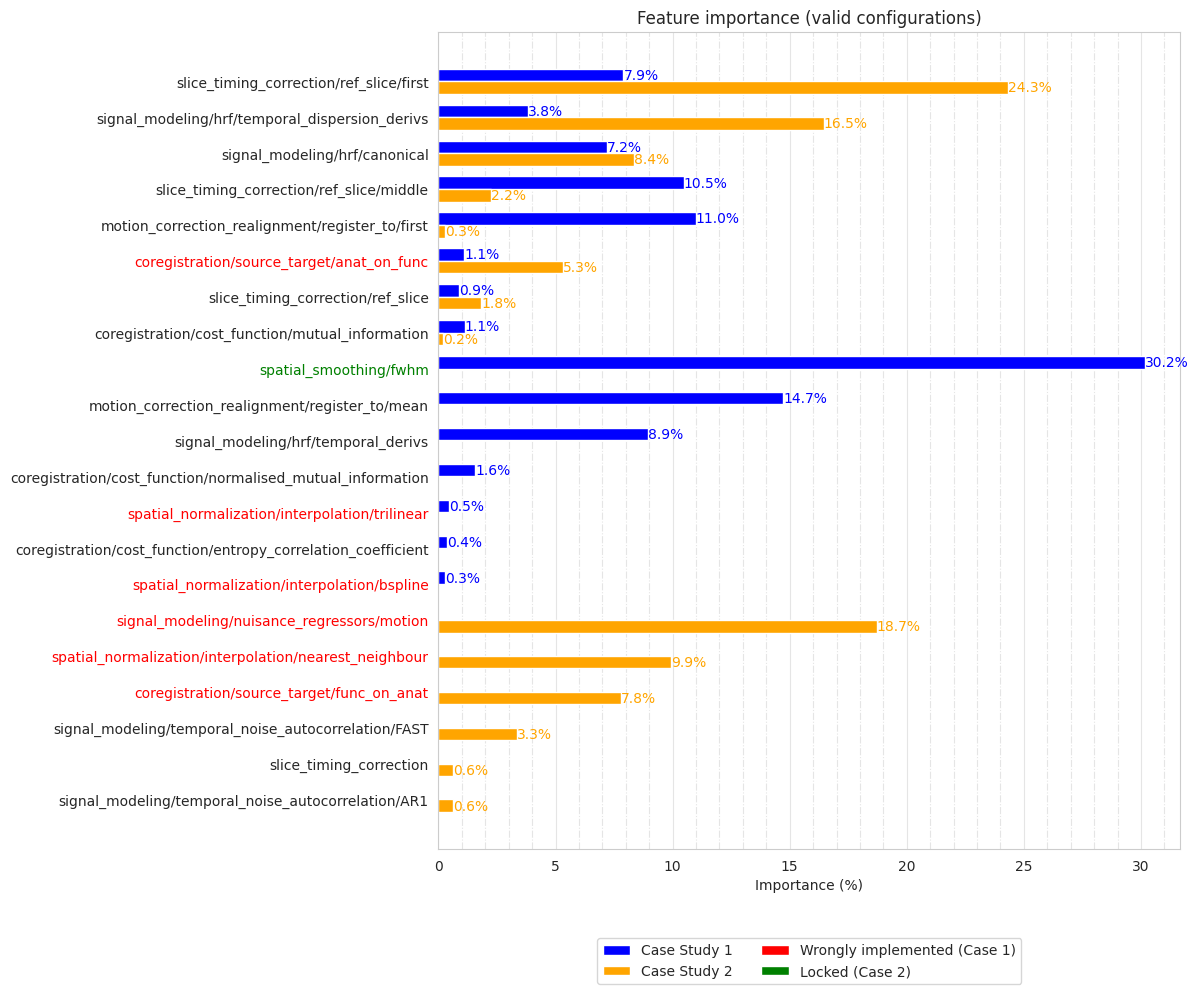

In [9]:
import numpy as np
from matplotlib import pyplot as plt

# List of features to highlight in red (if label starts with any of these)
kos_features = [
    "spatial_normalization/interpolation",
    "signal_modeling/nuisance_regressors",
    "coregistration/source_target"
]

# Feature to highlight in green (exact match)
locked_feature = "spatial_smoothing/fwhm"

# Get all unique features
all_features = set(feat_imp_1.keys()).union(set(feat_imp_2.keys()))

# Separate common and unique features
common_features = set(feat_imp_1.keys()).intersection(set(feat_imp_2.keys()))
unique_1 = set(feat_imp_1.keys()) - common_features
unique_2 = set(feat_imp_2.keys()) - common_features

# Order common features by decreasing mean importance
mean_importance = {f: (feat_imp_1[f] + feat_imp_2[f]) / 2 for f in common_features}
sorted_common = sorted(mean_importance.keys(), key=lambda x: mean_importance[x], reverse=True)

# Order unique features by decreasing importance
sorted_unique_1 = sorted(unique_1, key=lambda x: feat_imp_1[x], reverse=True)
sorted_unique_2 = sorted(unique_2, key=lambda x: feat_imp_2[x], reverse=True)

# Combine features in the desired order: common first, then unique_1, then unique_2
features = sorted_common + sorted_unique_1 + sorted_unique_2

# Align features and fill missing values with 0
importance_1 = [feat_imp_1.get(f, 0) for f in features]
importance_2 = [feat_imp_2.get(f, 0) for f in features]

# Convert to percentages
importance_1 = [i * 100 for i in importance_1]
importance_2 = [i * 100 for i in importance_2]

# Reverse the order to put common features on top
features = features[::-1]
importance_1 = importance_1[::-1]
importance_2 = importance_2[::-1]

# Plot
y = np.arange(len(features))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 10))
rects1 = ax.barh(y + width/2, importance_1, width, color='blue', label='Case Study 1')
rects2 = ax.barh(y - width/2, importance_2, width, color='orange', label='Case Study 2')

# Add percentage values at the end of each bar, only if greater than 0
for i, (v1, v2) in enumerate(zip(importance_1, importance_2)):
    if v1 > 0:
        ax.text(v1, i + width/2, f'{v1:.1f}%', color='blue', va='center', ha='left')
    if v2 > 0:
        ax.text(v2, i - width/2, f'{v2:.1f}%', color='orange', va='center', ha='left')

ax.set_xlabel('Importance (%)')
ax.set_title('Feature importance (valid configurations)')

# Set y-tick labels and color them
ax.set_yticks(y)
ax.set_yticklabels(features)
for i, label in enumerate(ax.get_yticklabels()):
    feature = features[i]
    # Check if the feature starts with any of the kos_features
    if any(feature.startswith(kos) for kos in kos_features):
        label.set_color('red')
    # Check if the feature matches exactly the locked_feature
    elif feature == locked_feature:
        label.set_color('green')

# Add a custom legend entry for wrongly implemented and locked features
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', label='Case Study 1'),
    Patch(facecolor='orange', label='Case Study 2'),
    Patch(facecolor='red', label='Wrongly implemented (Case 1)'),
    Patch(facecolor='green', label='Locked (Case 2)')
]
ax.legend(handles=legend_elements, loc='upper center', ncol=2, bbox_to_anchor=(0.5, -0.1))

plt.grid(False)
plt.minorticks_on()
plt.grid(True, linestyle="-.", alpha=0.5, which='minor', axis='x')
plt.grid(True, alpha=0.5, which='major', axis='x')

plt.tight_layout()
plt.savefig('feature_importances.svg', format='svg', bbox_inches='tight')
plt.savefig('feature_importances.png', format='png', bbox_inches='tight')
plt.show()


# F1-score, clusters, features by clustering threshold

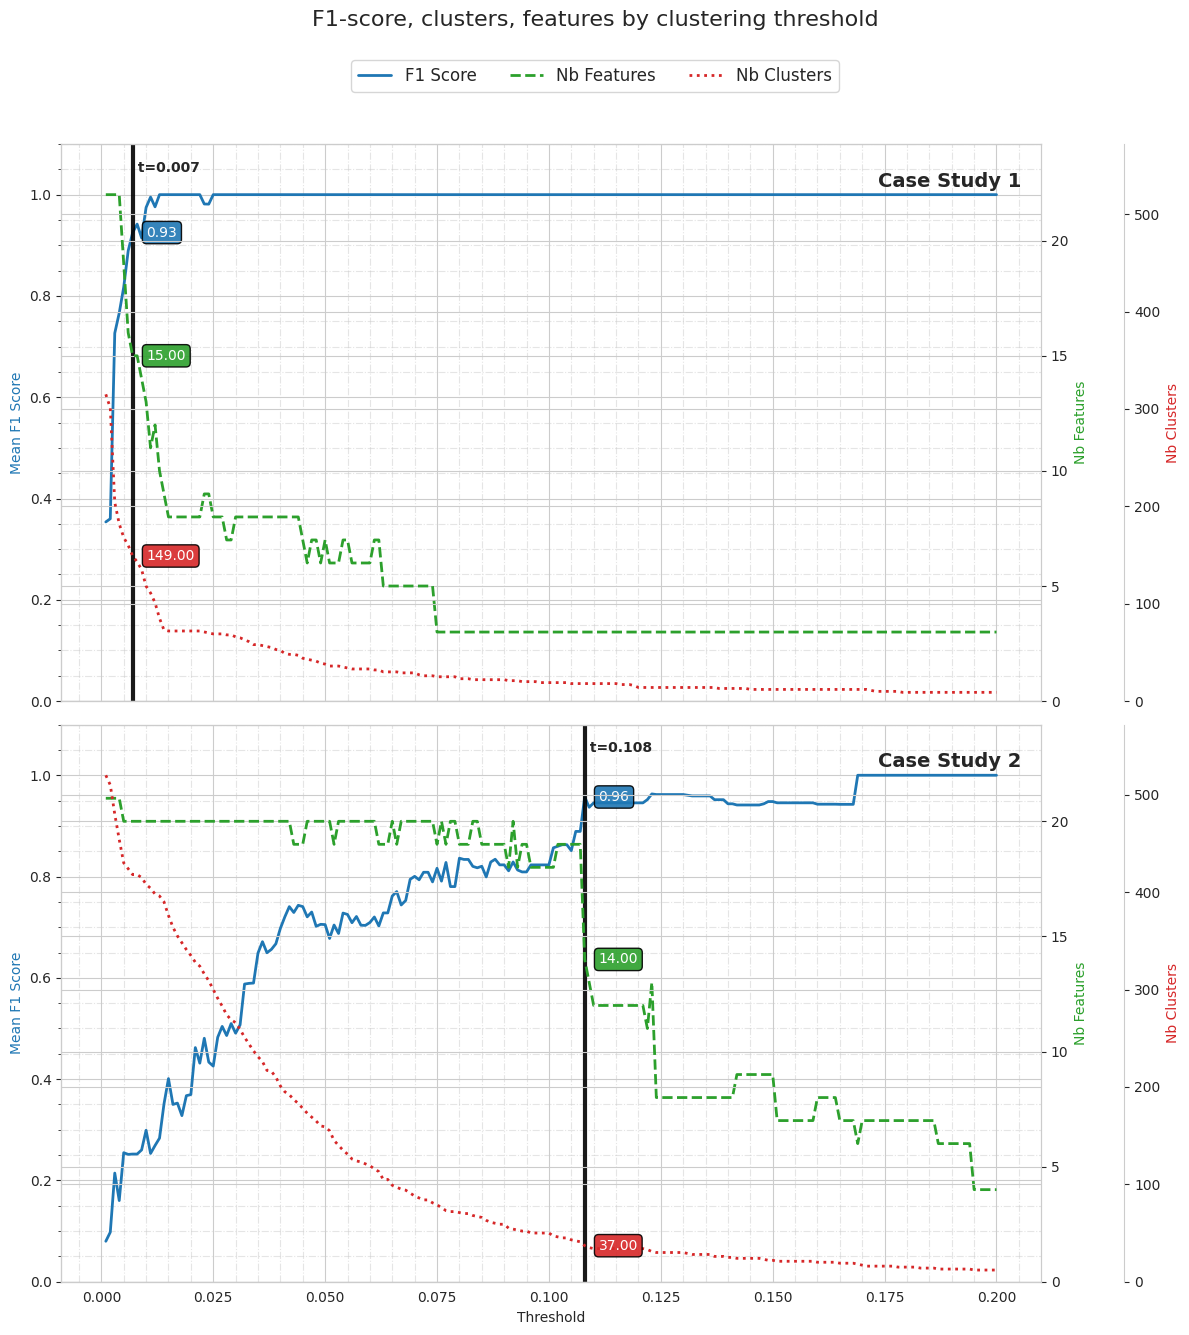

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

# --- Data Preparation ---
# Explicitly cast thresholds to float to prevent "sequence multiplication" errors
t1_val = float(threshold_1) if hasattr(threshold_1, '__iter__') and not isinstance(threshold_1, str) else float(threshold_1)
t2_val = float(threshold_2) if hasattr(threshold_2, '__iter__') and not isinstance(threshold_2, str) else float(threshold_2)

# Ensure numeric data for calculations
for df in [classifier_valid_thresholds_1, classifier_valid_thresholds_2]:
    for col in ['train_size', 'f1_score', 'nb_clusters', 'nb_features', 'threshold']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

max_train_size_1 = classifier_valid_thresholds_1['train_size'].max()
max_train_size_2 = classifier_valid_thresholds_2['train_size'].max()

filtered_df_1 = classifier_valid_thresholds_1[classifier_valid_thresholds_1['train_size'] == max_train_size_1]
filtered_df_2 = classifier_valid_thresholds_2[classifier_valid_thresholds_2['train_size'] == max_train_size_2]

relevant_columns = ['f1_score', 'nb_clusters', 'nb_features', 'threshold']
mean_df_1 = filtered_df_1[relevant_columns].groupby('threshold').mean().reset_index()
mean_df_2 = filtered_df_2[relevant_columns].groupby('threshold').mean().reset_index()

# Styles & Scales
styles = {
    'f1_score': {'color': '#1f77b4', 'ls': '-', 'label': 'F1 Score'},
    'nb_features': {'color': '#2ca02c', 'ls': '--', 'label': 'Nb Features'},
    'nb_clusters': {'color': '#d62728', 'ls': ':', 'label': 'Nb Clusters'}
}

# Synchronized Y-axis limits
y_limits = {
    'f1': (0, max(np.nanmax(mean_df_1['f1_score']), np.nanmax(mean_df_2['f1_score'])) * 1.1),
    'feat': (0, max(np.nanmax(mean_df_1['nb_features']), np.nanmax(mean_df_2['nb_features'])) * 1.1),
    'clus': (0, max(np.nanmax(mean_df_1['nb_clusters']), np.nanmax(mean_df_2['nb_clusters'])) * 1.1)
}

# Create Figure with vertical subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14), sharex=True)

panels = [
    (ax1, mean_df_1, "Case Study 1", t1_val, True),
    (ax2, mean_df_2, "Case Study 2", t2_val, False)
]

for main_ax, df, title, specific_t, is_top in panels:
    # 1. F1 Score Axis
    main_ax.plot(df['threshold'], df['f1_score'], **styles['f1_score'], linewidth=2)
    main_ax.set_ylim(y_limits['f1'])
    main_ax.set_ylabel('Mean F1 Score', color=styles['f1_score']['color'])

    if is_top:
        main_ax.set_xlabel('')  # Remove x-axis label for the top panel
    else:
        main_ax.set_xlabel('Threshold')  # Keep x-axis label for the bottom panel

    # 2. Features Axis
    ax_feat = main_ax.twinx()
    ax_feat.plot(df['threshold'], df['nb_features'], **styles['nb_features'], linewidth=2)
    ax_feat.set_ylim(y_limits['feat'])
    ax_feat.set_ylabel('Nb Features', color=styles['nb_features']['color'])

    # 3. Clusters Axis
    ax_clus = main_ax.twinx()
    ax_clus.spines['right'].set_position(('outward', 60))
    ax_clus.plot(df['threshold'], df['nb_clusters'], **styles['nb_clusters'], linewidth=2)
    ax_clus.set_ylim(y_limits['clus'])
    ax_clus.set_ylabel('Nb Clusters', color=styles['nb_clusters']['color'])

    # 4. Vertical Line & Annotations
    main_ax.axvline(x=specific_t, color='black', linestyle='-', linewidth=3, alpha=0.9)
    main_ax.text(0.98, 0.95, title, transform=main_ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='right', fontweight='bold')

    main_ax.text(specific_t, y_limits['f1'][1]*0.97, f' t={specific_t}', fontweight='bold', va='top')

    for col, ax_ref in [('f1_score', main_ax), ('nb_features', ax_feat), ('nb_clusters', ax_clus)]:
        y_val = np.interp(specific_t, df['threshold'], df[col])
        ax_ref.annotate(f'{y_val:.2f}', xy=(specific_t, y_val), xytext=(10, 0),
                        textcoords='offset points', color='white', va='center',
                        bbox=dict(boxstyle='round,pad=0.3', fc=styles[col]['color'], ec='black', alpha=0.9))

    main_ax.minorticks_on()
    main_ax.grid(True, linestyle="-.", alpha=0.5, which='minor', axis='both')

# Unified Legend and Figure Title
legend_elements = [Line2D([0], [0], **styles[k], lw=2) for k in styles]

fig.suptitle("F1-score, clusters, features by clustering threshold",
             fontsize=16, y=0.98)

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.95),
           ncol=3, frameon=True, fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.savefig('clustering_thresholds_metrics.png', format='png', bbox_inches='tight')
plt.savefig('clustering_thresholds_metrics.svg', format='svg', bbox_inches='tight')
plt.show()


In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from matplotlib.lines import Line2D

# --- 1. Setup ---
output_folder = "plots_output"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Clean and Round data to prevent floating point matching errors
for df in [classifier_valid_thresholds_1, classifier_valid_thresholds_2]:
    df['train_size'] = pd.to_numeric(df['train_size'], errors='coerce').round(4)
    df['f1_score'] = pd.to_numeric(df['f1_score'], errors='coerce')
    df['threshold'] = pd.to_numeric(df['threshold'], errors='coerce')

unique_train_sizes = sorted(classifier_valid_thresholds_1['train_size'].unique())
absolute_max_size = max(unique_train_sizes)

# --- 2. Iteration Loop ---
for current_size in unique_train_sizes:
    percentage = (current_size / absolute_max_size) * 100
    
    # Filter
    df1_sub = classifier_valid_thresholds_1[classifier_valid_thresholds_1['train_size'] == current_size]
    df2_sub = classifier_valid_thresholds_2[classifier_valid_thresholds_2['train_size'] == current_size]

    # CRITICAL CHECK: If data is empty, print a warning and skip
    if df1_sub.empty or df2_sub.empty:
        print(f"Skipping size {current_size}: No data found for this size.")
        continue

    # Aggregation
    mean_df_1 = df1_sub.groupby('threshold').mean(numeric_only=True).reset_index()
    mean_df_2 = df2_sub.groupby('threshold').mean(numeric_only=True).reset_index()

    # Create Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14), sharex=True)
    
    # Styles (re-declared inside or globally)
    styles = {'f1_score': {'color': '#1f77b4', 'ls': '-'}, 
              'nb_features': {'color': '#2ca02c', 'ls': '--'}, 
              'nb_clusters': {'color': '#d62728', 'ls': ':'}}

    panels = [(ax1, mean_df_1, "Case Study 1", t1_val), 
              (ax2, mean_df_2, "Case Study 2", t2_val)]

    for main_ax, df, title, spec_t in panels:
        # Plot F1
        main_ax.plot(df['threshold'], df['f1_score'], **styles['f1_score'], label='F1')
        main_ax.set_ylabel('F1 Score')
        
        # Plot Features
        ax_f = main_ax.twinx()
        ax_f.plot(df['threshold'], df['nb_features'], **styles['nb_features'])
        
        # Plot Clusters
        ax_c = main_ax.twinx()
        ax_c.spines['right'].set_position(('outward', 60))
        ax_c.plot(df['threshold'], df['nb_clusters'], **styles['nb_clusters'])
        
        main_ax.set_title(f"{title} - Size {percentage:.0f}%", loc='right', fontweight='bold')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # SAVE BEFORE CLOSE
    save_path = os.path.join(output_folder, f"plot_{int(percentage)}.png")
    plt.savefig(save_path)
    
    # DISPLAY
    plt.show() 
    plt.close(fig) 

print(f"Done. Check the folder: {os.path.abspath(output_folder)}")

Skipping size 105: No data found for this size.
Skipping size 157: No data found for this size.
Skipping size 210: No data found for this size.
Skipping size 263: No data found for this size.
Skipping size 315: No data found for this size.
Skipping size 368: No data found for this size.
Skipping size 420: No data found for this size.
Skipping size 473: No data found for this size.
Skipping size 526: No data found for this size.
Done. Check the folder: /home/ymerel/fmri/sosym_2026/src/plots_output
